# Cross-Basin TC Forecasting: Model Comparison (Extended)

Side-by-side evaluation of **six architectures** trained on WP, evaluated on SP:

**Original models:**
- FNO (Fourier Neural Operator) — baseline spectral approach
- ResNet-152 — standard CNN baseline
- U-Net with SE attention — spatial encoder-decoder

**Improved models (post-Hadrian feedback):**
- U-Net + FiLM — FiLM time conditioning at every level
- FNO v2 — spatial padding + 3 layers + FiLM time conditioning
- U-FNO — hybrid spectral + U-Net + residual branches with gated fusion

## 1. Setup & Data Loading

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Paths ──
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EXP_DIR  = PROJECT_ROOT / "checkpoints"
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64

N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ── Dataset (shared across all models) ──
class CycloneDataset(Dataset):
    """Flattens storm-level dicts into timestep-level samples.
    Filters sentinel labels (-1). 1D features z-scored with WP train stats.
    Returns 6-tuple: (grid, env, d1d, time_feat, dir_lbl, int_lbl)."""
    def __init__(self, grids, env, data1d, labels, time_feats=None,
                 use_reflected=False, d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"
        for storm_id in grids:
            g = grids[storm_id]
            e = env[storm_id]
            d = data1d[storm_id]
            t = time_feats[storm_id] if time_feats else torch.zeros(g.shape[0], 6)
            d_lbl = labels[storm_id][dir_key]
            i_lbl = labels[storm_id]["intensity"]
            for idx in range(g.shape[0]):
                if d_lbl[idx].item() == -1 or i_lbl[idx].item() == -1:
                    continue
                self.samples.append((
                    g[idx], e[idx], d[idx], t[idx],
                    d_lbl[idx].long(), i_lbl[idx].long()))
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(dim=0)
            self.d1d_std  = all_1d.std(dim=0).clamp(min=1e-6)
        else:
            self.d1d_mean, self.d1d_std = d1d_mean, d1d_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, tf, dir_lbl, int_lbl = self.samples[idx]
        d1d = (d1d - self.d1d_mean) / self.d1d_std
        return grid, env, d1d, tf, dir_lbl, int_lbl


# ── Load splits (with time features) ──
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"     / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d"  / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels"  / f"{split}_labels.pt", weights_only=False),
    }
    # Load time features if available
    time_path = DATA_DIR / "time" / f"{split}_time.pt"
    if time_path.exists():
        raw[split]["time"] = torch.load(time_path, weights_only=False)
    else:
        raw[split]["time"] = None

datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"],
    raw["wp_train"]["time"])
d1d_mean = datasets["wp_train"].d1d_mean
d1d_std  = datasets["wp_train"].d1d_std

for split, cfg in SPLITS.items():
    if split == "wp_train":
        continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], raw[split]["time"],
        use_reflected=cfg["reflected"],
        d1d_mean=d1d_mean, d1d_std=d1d_std)

loaders = {}
for split in SPLITS:
    loaders[split] = DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True)

for s, ds in datasets.items():
    print(f"  {s:15s}: {len(ds):5d} samples")

  wp_train       :  3252 samples
  wp_val         :   730 samples
  sp_test        :   367 samples
  sp_ft_train    :   354 samples
  sp_ft_val      :    81 samples


## 2. Model Definitions

Each architecture is defined below with the **exact same structure** used during training, so that saved checkpoints can be loaded directly.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Shared: SpectralConv2d + FiLMLayer (used by FNO, FNO v2, U-FNO)
# ═══════════════════════════════════════════════════════════════

class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes, padding=0):
        super().__init__()
        self.modes, self.out_ch, self.padding = modes, out_ch, padding
        s = (2/(in_ch+out_ch))**0.5
        self.w1 = nn.Parameter(s*(torch.rand(in_ch,out_ch,modes,modes,dtype=torch.cfloat)-0.5))
        self.w2 = nn.Parameter(s*(torch.rand(in_ch,out_ch,modes,modes,dtype=torch.cfloat)-0.5))
    def forward(self, x):
        if self.padding > 0: x = F.pad(x, [self.padding]*4, mode='reflect')
        B,C,H,W = x.shape
        xf = torch.fft.rfft2(x)
        of = torch.zeros(B,self.out_ch,H,W//2+1,dtype=torch.cfloat,device=x.device)
        of[:,:,:self.modes,:self.modes] = torch.einsum("bixy,ioxy->boxy",xf[:,:,:self.modes,:self.modes],self.w1)
        of[:,:,-self.modes:,:self.modes] = torch.einsum("bixy,ioxy->boxy",xf[:,:,-self.modes:,:self.modes],self.w2)
        x = torch.fft.irfft2(of, s=(H,W))
        if self.padding > 0: x = x[:,:,self.padding:-self.padding,self.padding:-self.padding]
        return x

class FiLMLayer(nn.Module):
    def __init__(self, cond_dim, ch):
        super().__init__()
        self.fc = nn.Linear(cond_dim, ch*2)
        nn.init.zeros_(self.fc.weight); nn.init.zeros_(self.fc.bias)
        self.fc.bias.data[:ch] = 1.0
    def forward(self, x, c):
        g, b = self.fc(c).chunk(2, 1)
        return g.unsqueeze(-1).unsqueeze(-1) * x + b.unsqueeze(-1).unsqueeze(-1)

# ═══════════════════════════════════════════════════════════════
# FNO baseline
# ═══════════════════════════════════════════════════════════════

class FNO2d(nn.Module):
    def __init__(self, in_ch=15, hidden=32, modes=12, n_layers=4, padding=0,
                 n_dir=8, n_int=4, env_dim=40, d1d_dim=4, dropout=0.05):
        super().__init__()
        self.lifting = nn.Sequential(nn.Conv2d(in_ch, hidden, 1), nn.GELU())
        self.spectral = nn.ModuleList([SpectralConv2d(hidden, hidden, modes, padding) for _ in range(n_layers)])
        self.skip = nn.ModuleList([nn.Conv2d(hidden, hidden, 1) for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.BatchNorm2d(hidden) for _ in range(n_layers)])
        self.drops = nn.ModuleList([nn.Dropout2d(dropout) for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(hidden, hidden, 1), nn.GELU())
        fuse = hidden + env_dim + d1d_dim
        self.head_dir = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),nn.Linear(128,n_dir))
        self.head_int = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),nn.Linear(128,n_int))

    def forward(self, grid, env=None, d1d=None, **kw):
        x = self.lifting(grid)
        for sp, sk, bn, dr in zip(self.spectral, self.skip, self.norms, self.drops):
            x = dr(F.gelu(bn(sp(x) + sk(x)))) + x
        x = self.proj(x).mean(dim=(-2,-1))
        f = torch.cat([x, env, d1d], 1)
        return self.head_dir(f), self.head_int(f)

In [4]:
# ═══════════════════════════════════════════════════════════════
# ResNet-152
# ═══════════════════════════════════════════════════════════════

import torchvision.models as tv_models

class ResNetClassifier(nn.Module):
    """ResNet backbone adapted for 15-channel 81x81 grids."""
    FEAT_DIMS = {"resnet18": 512, "resnet34": 512, "resnet50": 2048,
                 "resnet101": 2048, "resnet152": 2048}

    def __init__(self, resnet_size="resnet18", in_channels=15,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d
        backbone = getattr(tv_models, resnet_size)(weights=None)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = backbone.bn1
        self.act = nn.GELU()
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        feat_dim = self.FEAT_DIMS[resnet_size]
        aux_dim = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        head_in = feat_dim + aux_dim
        self.head_dir = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        x = self.act(self.bn1(self.conv1(grid)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d  and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, dim=-1)
        return self.head_dir(x), self.head_int(x)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# U-Net baseline (with SE attention, DropPath)
# ═══════════════════════════════════════════════════════════════

class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch//r,4)), nn.GELU(), nn.Linear(max(ch//r,4), ch), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        keep = torch.rand(x.size(0),1,1,1,device=x.device) > self.p
        return x * keep / (1 - self.p)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.drop2d = nn.Dropout2d(dropout)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        h = self.act(self.bn1(self.conv1(x)))
        h = self.drop2d(h)
        h = self.act(self.bn2(self.conv2(h)))
        return self.drop_path(h) + self.residual(x)

class UNet2d(nn.Module):
    def __init__(self, in_ch=15, base_ch=32, n_levels=4, n_dir=8, n_int=4,
                 env_dim=40, d1d_dim=4, dropout=0.2, head_dim=256, drop_path=0.1):
        super().__init__()
        dp = [drop_path * i / max(n_levels,1) for i in range(n_levels+1)]
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        ch = in_ch
        for i in range(n_levels):
            out = base_ch * (2**i)
            self.encoders.append(ConvBlock(ch, out, dropout, dp[i]))
            self.se_blocks.append(SEBlock(out))
            self.pools.append(nn.MaxPool2d(2, ceil_mode=True))
            ch = out
        bneck = base_ch * (2**n_levels)
        self.bottleneck = ConvBlock(ch, bneck, dropout, dp[n_levels])
        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()
        ch = bneck
        for i in range(n_levels-1, -1, -1):
            skip_ch = base_ch * (2**i)
            self.ups.append(nn.ConvTranspose2d(ch, ch, 2, stride=2))
            self.decoders.append(ConvBlock(ch + skip_ch, skip_ch, dropout, dp[i]))
            ch = skip_ch
        self.gap = nn.AdaptiveAvgPool2d(1)
        fuse = base_ch + env_dim + d1d_dim
        self.head_dir = nn.Sequential(nn.Linear(fuse,head_dim),nn.GELU(),nn.Dropout(dropout*2),
            nn.Linear(head_dim,head_dim//2),nn.GELU(),nn.Dropout(dropout),nn.Linear(head_dim//2,n_dir))
        self.head_int = nn.Sequential(nn.Linear(fuse,head_dim),nn.GELU(),nn.Dropout(dropout*2),
            nn.Linear(head_dim,head_dim//2),nn.GELU(),nn.Dropout(dropout),nn.Linear(head_dim//2,n_int))

    def forward(self, grid, env=None, d1d=None, **kw):
        skips = []
        x = grid
        for enc, se, pool in zip(self.encoders, self.se_blocks, self.pools):
            x = se(enc(x)); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            dh, dw = x.size(2)-skip.size(2), x.size(3)-skip.size(3)
            if dh > 0 or dw > 0: x = x[:,:,dh//2:dh//2+skip.size(2),dw//2:dw//2+skip.size(3)]
            elif dh < 0 or dw < 0: x = F.pad(x, [0,-dw,0,-dh])
            x = dec(torch.cat([x, skip], 1))
        x = self.gap(x).flatten(1)
        parts = [x]
        if env is not None: parts.append(env)
        if d1d is not None: parts.append(d1d)
        f = torch.cat(parts, 1)
        return self.head_dir(f), self.head_int(f)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# U-Net + FiLM (temporal conditioning at every conv block)
# ═══════════════════════════════════════════════════════════════

class FiLMConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.drop2d = nn.Dropout2d(dropout)
        self.film = FiLMLayer(cond_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.drop_path = DropPath(drop_path)

    def forward(self, x, cond):
        h = self.act(self.bn1(self.conv1(x)))
        h = self.drop2d(h)
        h = self.bn2(self.conv2(h))
        h = self.film(h, cond)
        h = self.act(h)
        return self.drop_path(h) + self.residual(x)

class UNetFiLM2d(nn.Module):
    def __init__(self, in_ch=15, base_ch=32, n_levels=4, n_dir=8, n_int=4,
                 env_dim=40, d1d_dim=4, time_dim=6, time_emb=64,
                 dropout=0.2, head_dim=256, drop_path=0.1):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(time_dim,time_emb),nn.GELU(),nn.Linear(time_emb,time_emb))
        dp = [drop_path*i/max(n_levels,1) for i in range(n_levels+1)]
        self.encoders = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(n_levels):
            out = base_ch*(2**i)
            self.encoders.append(FiLMConvBlock(ch, out, time_emb, dropout, dp[i]))
            self.se_blocks.append(SEBlock(out))
            self.pools.append(nn.MaxPool2d(2, ceil_mode=True))
            ch = out
        bneck = base_ch*(2**n_levels)
        self.bottleneck = FiLMConvBlock(ch, bneck, time_emb, dropout, dp[n_levels])
        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()
        ch = bneck
        for i in range(n_levels-1,-1,-1):
            skip_ch = base_ch*(2**i)
            self.ups.append(nn.ConvTranspose2d(ch, ch, 2, stride=2))
            self.decoders.append(FiLMConvBlock(ch+skip_ch, skip_ch, time_emb, dropout, dp[i]))
            ch = skip_ch
        self.gap = nn.AdaptiveAvgPool2d(1)
        fuse = base_ch + env_dim + d1d_dim
        self.head_dir = nn.Sequential(nn.Linear(fuse,head_dim),nn.GELU(),nn.Dropout(dropout*2),
            nn.Linear(head_dim,head_dim//2),nn.GELU(),nn.Dropout(dropout),nn.Linear(head_dim//2,n_dir))
        self.head_int = nn.Sequential(nn.Linear(fuse,head_dim),nn.GELU(),nn.Dropout(dropout*2),
            nn.Linear(head_dim,head_dim//2),nn.GELU(),nn.Dropout(dropout),nn.Linear(head_dim//2,n_int))

    def forward(self, grid, env=None, d1d=None, time_feat=None, **kw):
        t = self.time_mlp(time_feat)
        skips = []; x = grid
        for enc, se, pool in zip(self.encoders, self.se_blocks, self.pools):
            x = se(enc(x, t)); skips.append(x); x = pool(x)
        x = self.bottleneck(x, t)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            dh, dw = x.size(2)-skip.size(2), x.size(3)-skip.size(3)
            if dh > 0 or dw > 0: x = x[:,:,dh//2:dh//2+skip.size(2),dw//2:dw//2+skip.size(3)]
            elif dh < 0 or dw < 0: x = F.pad(x, [0,-dw,0,-dh])
            x = dec(torch.cat([x, skip], 1), t)
        x = self.gap(x).flatten(1)
        f = torch.cat([x, env, d1d], 1)
        return self.head_dir(f), self.head_int(f)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FNO v2 (padded spectral conv + FiLM time conditioning)
# ═══════════════════════════════════════════════════════════════

class FNOv2(nn.Module):
    def __init__(self, in_ch=15, hidden=32, modes=12, n_layers=3, padding=9,
                 n_dir=8, n_int=4, env_dim=40, d1d_dim=4, time_dim=6, time_emb=64, dropout=0.05):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(time_dim,time_emb),nn.GELU(),nn.Linear(time_emb,time_emb))
        self.lifting = nn.Sequential(nn.Conv2d(in_ch, hidden, 1), nn.GELU())
        self.spectral = nn.ModuleList([SpectralConv2d(hidden, hidden, modes, padding) for _ in range(n_layers)])
        self.skip = nn.ModuleList([nn.Conv2d(hidden, hidden, 1) for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.BatchNorm2d(hidden) for _ in range(n_layers)])
        self.films = nn.ModuleList([FiLMLayer(time_emb, hidden) for _ in range(n_layers)])
        self.drops = nn.ModuleList([nn.Dropout2d(dropout) for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(hidden, hidden, 1), nn.GELU())
        fuse = hidden + env_dim + d1d_dim
        self.head_dir = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),nn.Linear(128,n_dir))
        self.head_int = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),nn.Linear(128,n_int))

    def forward(self, grid, env=None, d1d=None, time_feat=None, **kw):
        t = self.time_mlp(time_feat) if time_feat is not None else None
        x = self.lifting(grid)
        for sp, sk, bn, film, dr in zip(self.spectral, self.skip, self.norms, self.films, self.drops):
            h = bn(sp(x) + sk(x))
            if t is not None: h = film(h, t)
            x = dr(F.gelu(h)) + x
        x = self.proj(x).mean(dim=(-2,-1))
        f = torch.cat([x, env, d1d], 1)
        return self.head_dir(f), self.head_int(f)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# U-FNO (gated hybrid: spectral + U-Net branch + residual)
# ═══════════════════════════════════════════════════════════════

class UNetBranch(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(ch,ch,3,stride=2,padding=1,bias=False),nn.BatchNorm2d(ch),nn.GELU())
        self.mid = nn.Sequential(nn.Conv2d(ch,ch,3,padding=1,bias=False),nn.BatchNorm2d(ch),nn.GELU())
        self.up = nn.ConvTranspose2d(ch,ch,2,stride=2)
        self.fuse = nn.Sequential(nn.Conv2d(ch*2,ch,1,bias=False),nn.BatchNorm2d(ch))
    def forward(self, x):
        skip = x; x = self.mid(self.down(x)); x = self.up(x)
        if x.shape != skip.shape: x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], 1))

class UFNO2d(nn.Module):
    def __init__(self, in_ch=15, hidden=32, modes=12, n_layers=3, padding=9,
                 n_dir=8, n_int=4, env_dim=40, d1d_dim=4, time_dim=6, time_emb=64, dropout=0.1):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(time_dim,time_emb),nn.GELU(),nn.Linear(time_emb,time_emb))
        self.lifting = nn.Sequential(nn.Conv2d(in_ch,hidden,1),nn.GELU())
        self.blocks = nn.ModuleList()
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "spectral": SpectralConv2d(hidden, hidden, modes, padding),
                "unet": UNetBranch(hidden),
                "residual": nn.Conv2d(hidden, hidden, 1),
                "gate": nn.ParameterDict({"w": nn.Parameter(torch.ones(3)/3)}),
                "norm": nn.BatchNorm2d(hidden),
                "film": FiLMLayer(time_emb, hidden),
                "drop": nn.Dropout2d(dropout),
            }))
        self.proj = nn.Sequential(nn.Conv2d(hidden,hidden,1),nn.GELU())
        fuse = hidden + env_dim + d1d_dim
        self.head_dir = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),
            nn.Linear(128,64),nn.GELU(),nn.Dropout(0.1),nn.Linear(64,n_dir))
        self.head_int = nn.Sequential(nn.Linear(fuse,128),nn.GELU(),nn.Dropout(0.2),
            nn.Linear(128,64),nn.GELU(),nn.Dropout(0.1),nn.Linear(64,n_int))

    def forward(self, grid, env=None, d1d=None, time_feat=None, **kw):
        t = self.time_mlp(time_feat) if time_feat is not None else None
        x = self.lifting(grid)
        for blk in self.blocks:
            g = F.softmax(blk["gate"]["w"], dim=0)
            out = g[0]*blk["spectral"](x) + g[1]*blk["unet"](x) + g[2]*blk["residual"](x)
            out = blk["norm"](out)
            if t is not None: out = blk["film"](out, t)
            x = blk["drop"](F.gelu(out)) + x
        x = self.proj(x).mean(dim=(-2,-1))
        f = torch.cat([x, env, d1d], 1)
        return self.head_dir(f), self.head_int(f)

## 3. Load Checkpoints

In [ ]:
def load_model(cls, ckpt_path, **kwargs):
    """Instantiate model and load state_dict."""
    model = cls(**kwargs)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  {cls.__name__:25s} | {n_params:>10,d} params | loaded from {ckpt_path.name}")
    return model


# ── Hyperparameters from HPO (matching checkpoints exactly) ──

# FNO baseline: hidden=64, modes=15, n_layers=4, padding=0
FNO_KW = dict(in_ch=15, hidden=64, modes=15, n_layers=4, padding=0, dropout=0.05)
# FNO v2: hidden=48, modes=20, n_layers=5, padding=9, time_emb=64
FNOV2_KW = dict(in_ch=15, hidden=48, modes=20, n_layers=5, padding=9, time_emb=64, dropout=0.05)
# U-Net: base_ch=32, n_levels=5, head_dim=256, drop_path=0.065
UNET_KW = dict(in_ch=15, base_ch=32, n_levels=5, dropout=0.118, head_dim=256, drop_path=0.065)
# U-Net+FiLM: base_ch=48, n_levels=3, head_dim=512, time_emb=64
UNET_FILM_KW = dict(in_ch=15, base_ch=48, n_levels=3, dropout=0.207, head_dim=512, time_emb=64, drop_path=0.1)
# U-FNO: hidden=48, modes=16, n_layers=2, padding=13
UFNO_KW = dict(in_ch=15, hidden=48, modes=16, n_layers=2, padding=13, time_emb=64, dropout=0.114)
# ResNet-152: head_dim=128
RESNET_KW = dict(resnet_size="resnet152", in_channels=15, head_dim=128, dropout=0.1)

# ── WP-trained models (baseline) ──
print("WP-trained models (baseline, zero-shot):")
fno_wp = load_model(FNO2d, EXP_DIR / "fno_best_wp.pt", **FNO_KW)
resnet_wp = load_model(ResNetClassifier, EXP_DIR / "resnet_best_wp.pt", **RESNET_KW)
unet_wp = load_model(UNet2d, EXP_DIR / "unet_best_wp.pt", **UNET_KW)

# ── WP-trained models (new architectures) ──
print("\nWP-trained models (new architectures):")
unet_film_wp = load_model(UNetFiLM2d, EXP_DIR / "unet_film_best_wp.pt", **UNET_FILM_KW)
fno_v2_wp = load_model(FNOv2, EXP_DIR / "fno_v2_best_wp.pt", **FNOV2_KW)
ufno_wp = load_model(UFNO2d, EXP_DIR / "ufno_best_wp.pt", **UFNO_KW)

# ── Fine-tuned models (baseline) ──
print("\nFine-tuned models (baseline, SP):")
fno_ft = load_model(FNO2d, EXP_DIR / "fno_best_ft.pt", **FNO_KW)
resnet_ft = load_model(ResNetClassifier, EXP_DIR / "resnet_best_ft.pt", **RESNET_KW)
unet_ft = load_model(UNet2d, EXP_DIR / "unet_best_ft.pt", **UNET_KW)

# ── Fine-tuned models (new architectures) ──
print("\nFine-tuned models (new architectures, SP):")
unet_film_ft = load_model(UNetFiLM2d, EXP_DIR / "unet_film_best_ft.pt", **UNET_FILM_KW)
fno_v2_ft = load_model(FNOv2, EXP_DIR / "fno_v2_best_ft.pt", **FNOV2_KW)
ufno_ft = load_model(UFNO2d, EXP_DIR / "ufno_best_ft.pt", **UFNO_KW)

## 4. Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, loader, uses_time=False):
    """Returns dict with dir/int accuracy, macro-F1, and raw predictions."""
    model.eval()
    dir_preds, dir_trues = [], []
    int_preds, int_trues = [], []
    for batch in loader:
        grid, env, d1d, time_feat, dl, il = batch
        grid = grid.to(DEVICE)
        env  = env.to(DEVICE)
        d1d  = d1d.to(DEVICE)
        if uses_time:
            time_feat = time_feat.to(DEVICE)
            d_out, i_out = model(grid, env, d1d, time_feat=time_feat)
        else:
            d_out, i_out = model(grid, env, d1d)
        dir_preds.extend(d_out.argmax(1).cpu().tolist())
        int_preds.extend(i_out.argmax(1).cpu().tolist())
        dir_trues.extend(dl.tolist())
        int_trues.extend(il.tolist())
    return {
        "dir_acc": accuracy_score(dir_trues, dir_preds),
        "dir_f1":  f1_score(dir_trues, dir_preds, average="macro", zero_division=0),
        "int_acc": accuracy_score(int_trues, int_preds),
        "int_f1":  f1_score(int_trues, int_preds, average="macro", zero_division=0),
        "dir_preds": dir_preds, "dir_trues": dir_trues,
        "int_preds": int_preds, "int_trues": int_trues,
    }


# ── Model registry ──
MODEL_NAMES = ["FNO", "ResNet-152", "U-Net", "U-Net+FiLM", "FNO v2", "U-FNO"]
wp_models   = [fno_wp, resnet_wp, unet_wp, unet_film_wp, fno_v2_wp, ufno_wp]
ft_models   = [fno_ft, resnet_ft, unet_ft, unet_film_ft, fno_v2_ft, ufno_ft]
uses_time   = [False,  False,      False,   True,          True,      True]

results = {}
for name, m_wp, m_ft, ut in zip(MODEL_NAMES, wp_models, ft_models, uses_time):
    results[name] = {}
    results[name]["WP Val"]        = evaluate(m_wp, loaders["wp_val"], uses_time=ut)
    results[name]["SP Zero-Shot"]  = evaluate(m_wp, loaders["sp_test"], uses_time=ut)
    results[name]["SP Fine-Tuned"] = evaluate(m_ft, loaders["sp_test"], uses_time=ut)
    print(f"{name:12s} | WP dir={results[name]['WP Val']['dir_acc']:.3f}  "
          f"SP-ZS dir={results[name]['SP Zero-Shot']['dir_acc']:.3f}  "
          f"SP-FT dir={results[name]['SP Fine-Tuned']['dir_acc']:.3f}")

## 5. Results Summary Table

In [ ]:
import pandas as pd

# ── Build comparison table ──
rows = []
for name in MODEL_NAMES:
    for setting in ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]:
        m = results[name][setting]
        rows.append({
            "Model": name,
            "Setting": setting,
            "Dir Acc": m["dir_acc"],
            "Dir F1":  m["dir_f1"],
            "Int Acc": m["int_acc"],
            "Int F1":  m["int_f1"],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format="{:.3f}".format))
df

     Model       Setting  Dir Acc  Dir F1  Int Acc  Int F1
       FNO        WP Val    0.503   0.364    0.558   0.410
       FNO  SP Zero-Shot    0.248   0.217    0.357   0.300
       FNO SP Fine-Tuned    0.346   0.272    0.335   0.288
ResNet-152        WP Val    0.512   0.404    0.549   0.463
ResNet-152  SP Zero-Shot    0.272   0.212    0.384   0.319
ResNet-152 SP Fine-Tuned    0.294   0.234    0.501   0.430
     U-Net        WP Val    0.625   0.447    0.510   0.433
     U-Net  SP Zero-Shot    0.414   0.293    0.360   0.291
     U-Net SP Fine-Tuned    0.401   0.309    0.450   0.367


,Model,Setting,Dir Acc,Dir F1,Int Acc,Int F1
0,FNO,WP Val,0.502740,0.364079,0.557534,0.409808
1,FNO,SP Zero-Shot,0.247956,0.217372,0.356948,0.300373
2,FNO,SP Fine-Tuned,0.346049,0.272140,0.335150,0.287632
3,ResNet-152,WP Val,0.512329,0.403719,0.549315,0.462675
4,ResNet-152,SP Zero-Shot,0.272480,0.212319,0.384196,0.319088
5,ResNet-152,SP Fine-Tuned,0.294278,0.234066,0.501362,0.429789
6,U-Net,WP Val,0.624658,0.446621,0.509589,0.432895
7,U-Net,SP Zero-Shot,0.414169,0.292830,0.359673,0.291400
8,U-Net,SP Fine-Tuned,0.400545,0.308956,0.449591,0.366986


In [ ]:
# ── Transfer gap & fine-tuning recovery ──
gap_rows = []
for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    gap_rows.append({
        "Model": name,
        "WP Val Dir Acc": wp,
        "SP Zero-Shot Dir Acc": zs,
        "Transfer Gap": zs - wp,
        "SP Fine-Tuned Dir Acc": ft,
        "FT Recovery": ft - zs,
    })

df_gap = pd.DataFrame(gap_rows)
print(df_gap.to_string(index=False, float_format="{:.3f}".format))
df_gap

     Model  WP Val Dir Acc  SP Zero-Shot Dir Acc  Transfer Gap  SP Fine-Tuned Dir Acc  FT Recovery
       FNO           0.503                 0.248        -0.255                  0.346        0.098
ResNet-152           0.512                 0.272        -0.240                  0.294        0.022
     U-Net           0.625                 0.414        -0.210                  0.401       -0.014


,Model,WP Val Dir Acc,SP Zero-Shot Dir Acc,Transfer Gap,SP Fine-Tuned Dir Acc,FT Recovery
0,FNO,0.502740,0.247956,-0.254783,0.346049,0.098093
1,ResNet-152,0.512329,0.272480,-0.239849,0.294278,0.021798
2,U-Net,0.624658,0.414169,-0.210489,0.400545,-0.013624


## 6. Comparison Bar Charts

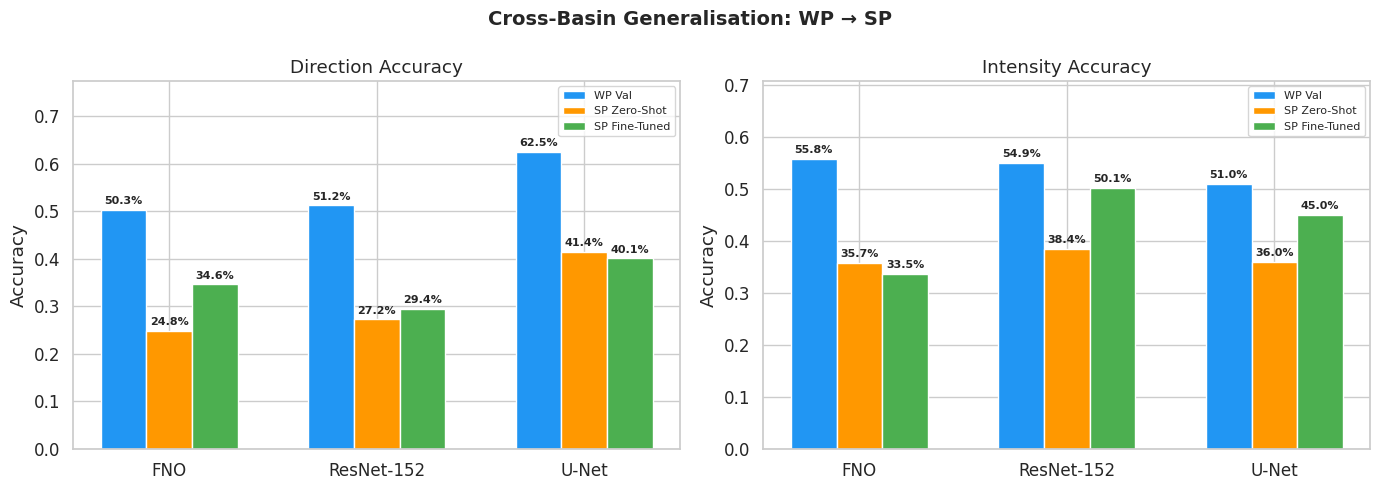

In [ ]:
# ── Direction & Intensity accuracy: grouped bar chart ──
settings = ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]
colours  = ["#2196F3", "#FF9800", "#4CAF50"]
x = np.arange(len(MODEL_NAMES))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, title in zip(
        axes, ["dir_acc", "int_acc"], ["Direction Accuracy", "Intensity Accuracy"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: WP → SP", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_accuracy_bars.png", dpi=200, bbox_inches="tight")
plt.show()

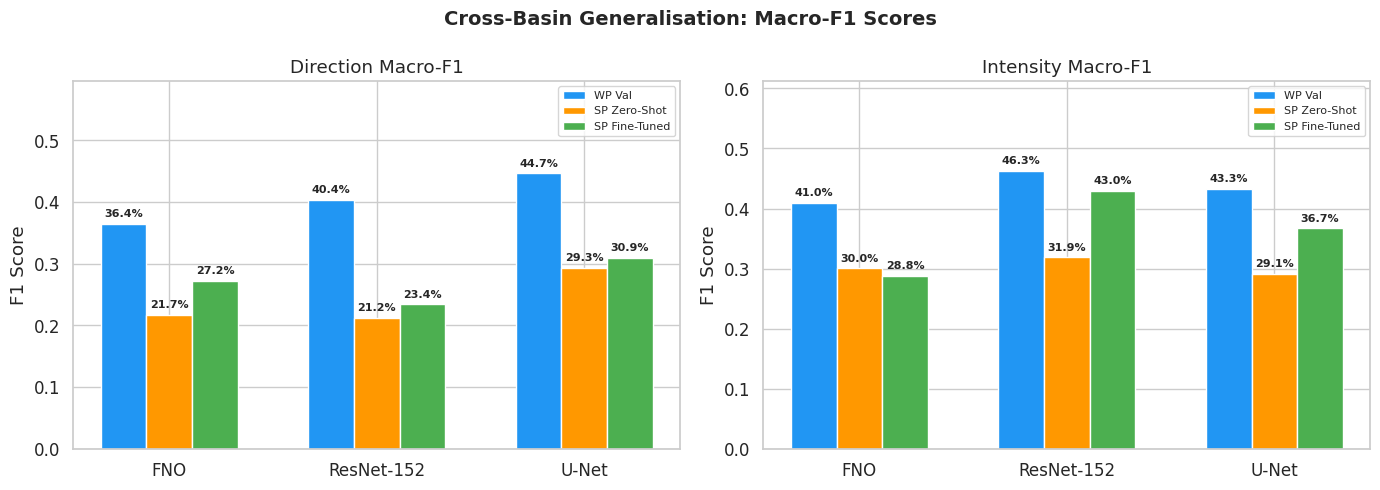

In [ ]:
# ── Macro F1: grouped bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, title in zip(
        axes, ["dir_f1", "int_f1"], ["Direction Macro-F1", "Intensity Macro-F1"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: Macro-F1 Scores", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_f1_bars.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices (SP Zero-Shot)

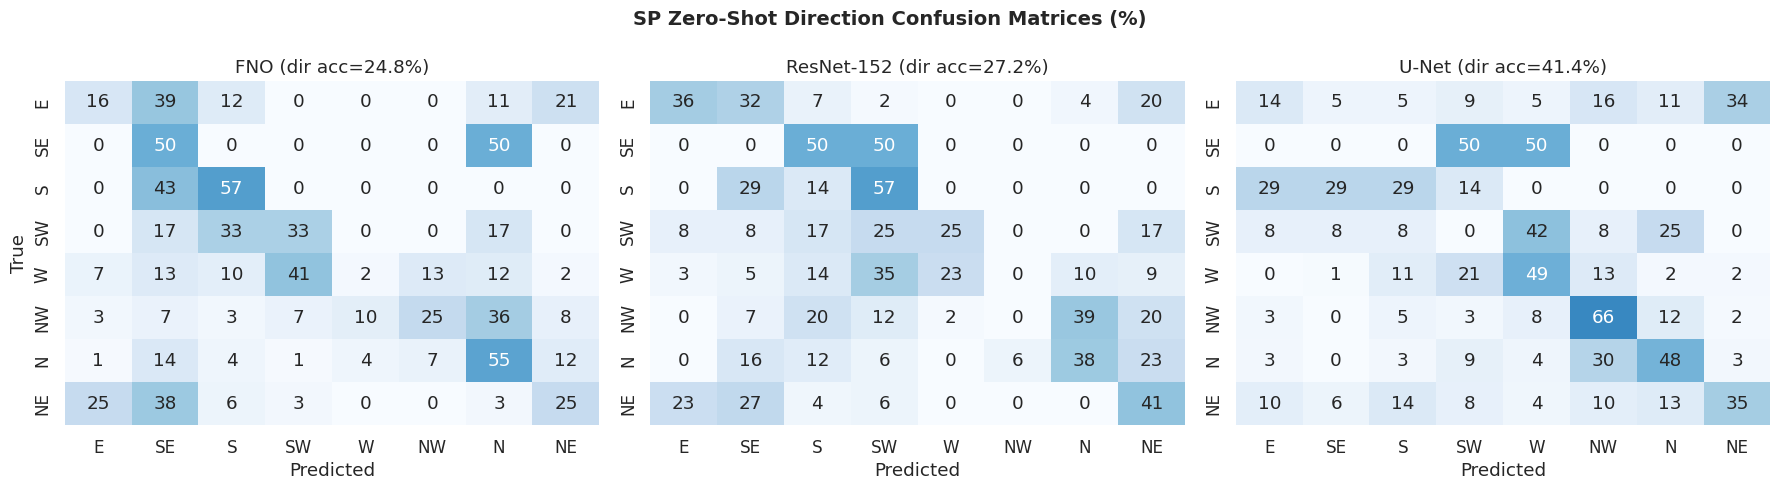

In [ ]:
# ── Direction confusion matrices: zero-shot SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Zero-Shot Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

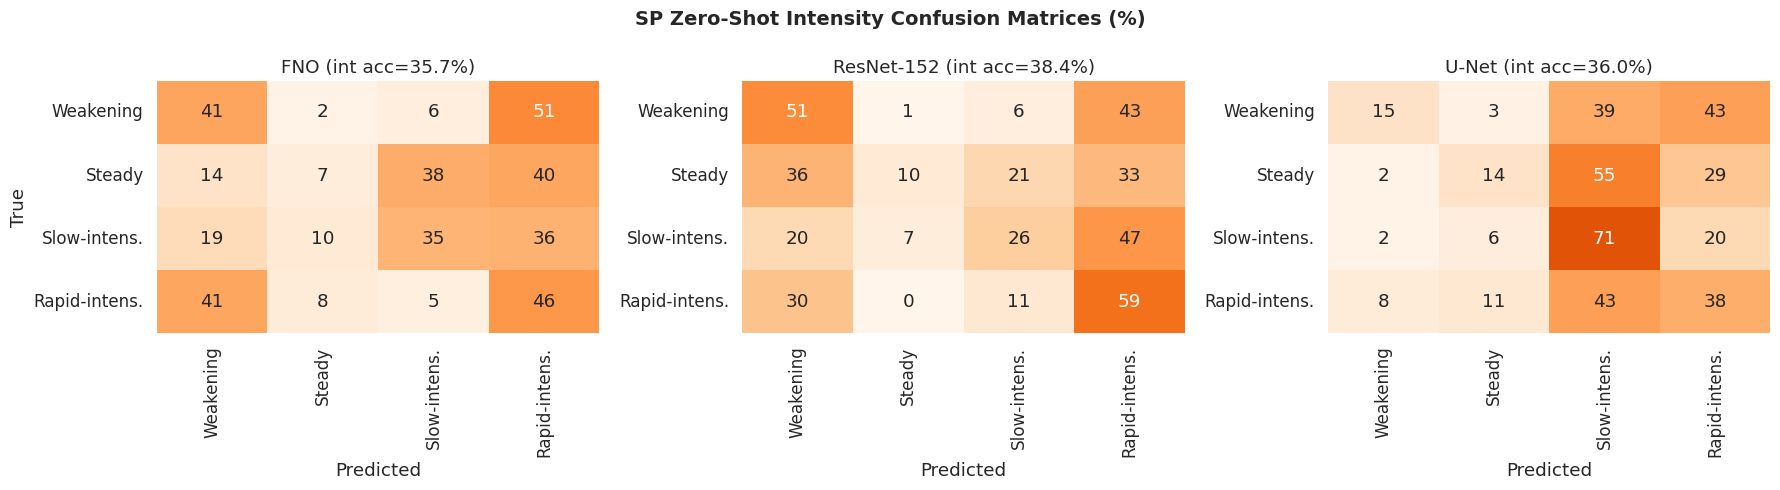

In [ ]:
# ── Intensity confusion matrices: zero-shot SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["int_trues"], m["int_preds"], labels=range(N_INT_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Oranges",
                xticklabels=INTE_LABELS, yticklabels=INTE_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (int acc={m['int_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Zero-Shot Intensity Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_int_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Fine-Tuning Impact

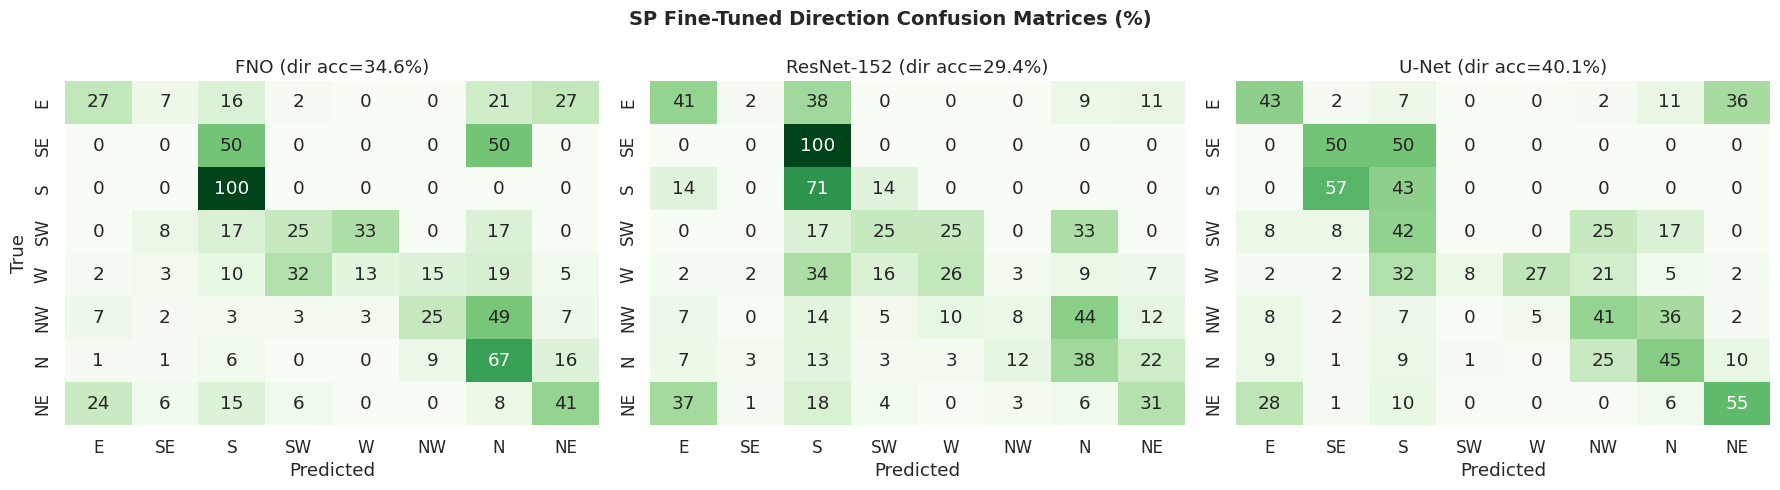

In [ ]:
# ── Direction confusion matrices: fine-tuned SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Fine-Tuned"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Greens",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Fine-Tuned Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_finetuned.png", dpi=200, bbox_inches="tight")
plt.show()

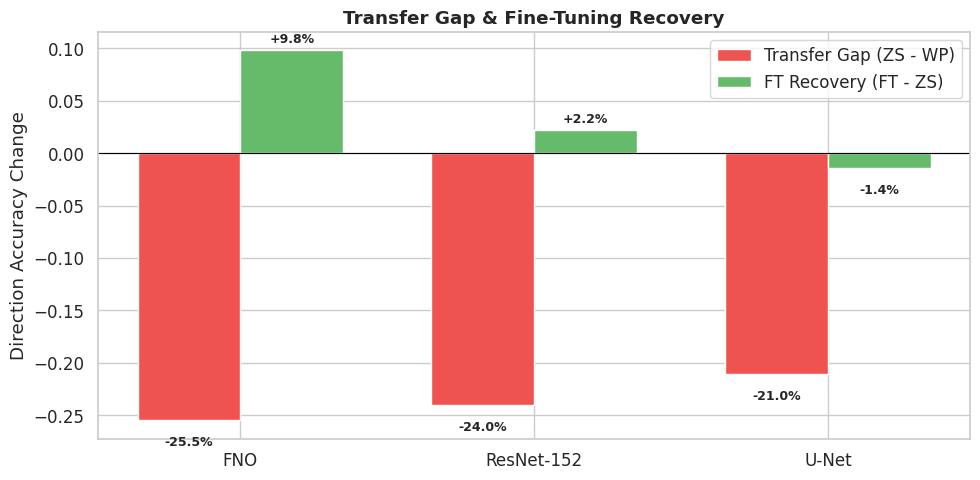

In [ ]:
# ── Transfer gap waterfall chart ──
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(MODEL_NAMES))
w = 0.35

gaps = [results[n]["SP Zero-Shot"]["dir_acc"] - results[n]["WP Val"]["dir_acc"]
        for n in MODEL_NAMES]
recoveries = [results[n]["SP Fine-Tuned"]["dir_acc"] - results[n]["SP Zero-Shot"]["dir_acc"]
              for n in MODEL_NAMES]

bars1 = ax.bar(x - w/2, gaps, w, label="Transfer Gap (ZS - WP)",
               color="#EF5350", edgecolor="white")
bars2 = ax.bar(x + w/2, recoveries, w, label="FT Recovery (FT - ZS)",
               color="#66BB6A", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.005 if h >= 0 else -0.015),
                f"{h:+.1%}", ha="center", va="bottom" if h >= 0 else "top",
                fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
ax.set_ylabel("Direction Accuracy Change")
ax.set_title("Transfer Gap & Fine-Tuning Recovery", fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_transfer_gap.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Per-Class F1 Comparison

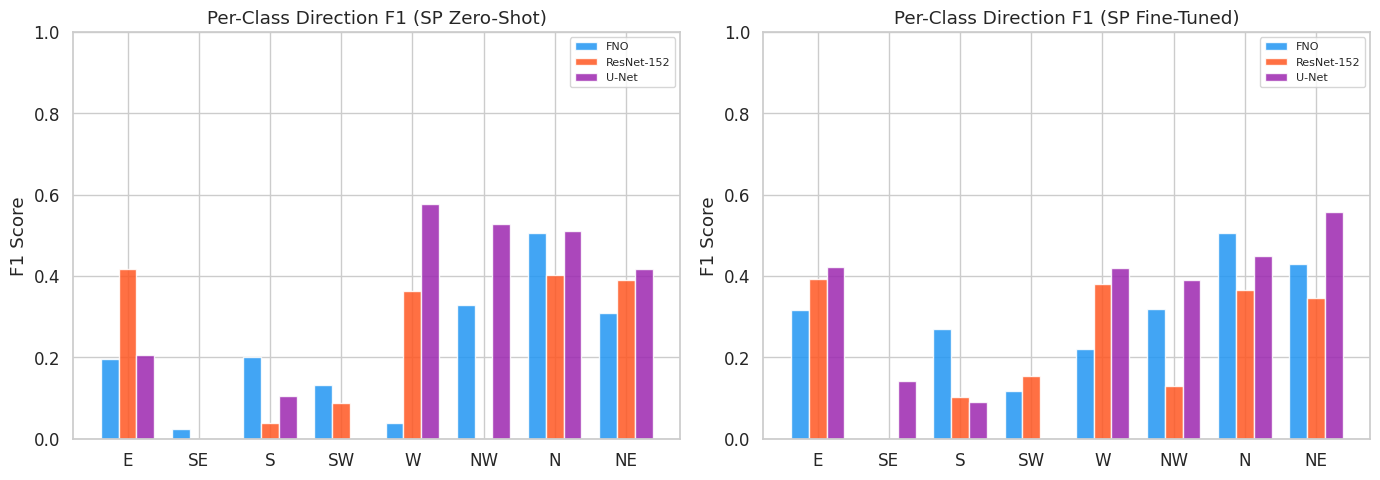

In [ ]:
from sklearn.metrics import f1_score as f1_fn

# ── Per-class direction F1 on SP zero-shot ──
model_colours = ["#2196F3", "#FF5722", "#9C27B0", "#009688", "#E91E63", "#795548"]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, setting, title in zip(axes, ["SP Zero-Shot", "SP Fine-Tuned"],
                               ["SP Zero-Shot", "SP Fine-Tuned"]):
    x_cls = np.arange(N_DIR_CLASSES)
    w_cls = 0.8 / len(MODEL_NAMES)
    for i, (name, col) in enumerate(zip(MODEL_NAMES, model_colours)):
        m = results[name][setting]
        per_f1 = f1_fn(m["dir_trues"], m["dir_preds"],
                        labels=range(N_DIR_CLASSES), average=None, zero_division=0)
        ax.bar(x_cls + i * w_cls, per_f1, w_cls, label=name, color=col,
               edgecolor="white", alpha=0.85)
    ax.set_xticks(x_cls + w_cls * len(MODEL_NAMES) / 2)
    ax.set_xticklabels(DIR_LABELS)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Per-Class Direction F1 ({title})")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_perclass_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Radar Chart: Multi-Metric Comparison

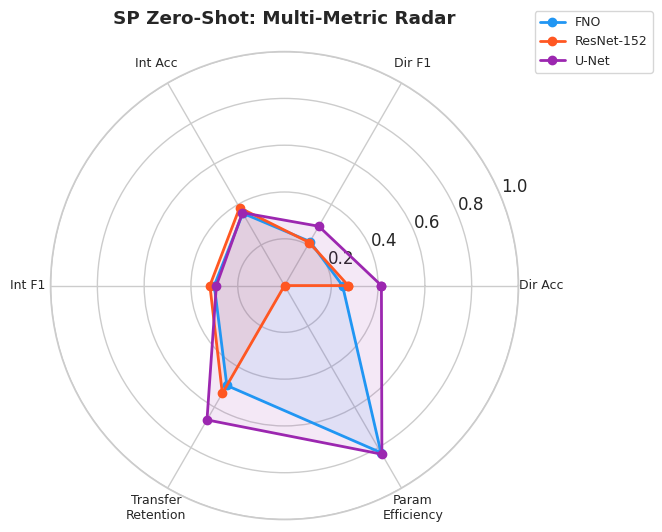

In [ ]:
# ── Radar chart: 6 metrics per model (SP zero-shot) ──
metrics_radar = ["dir_acc", "dir_f1", "int_acc", "int_f1"]
metric_labels = ["Dir Acc", "Dir F1", "Int Acc", "Int F1"]
model_colours = ["#2196F3", "#FF5722", "#9C27B0", "#009688", "#E91E63", "#795548"]

param_counts = {}
for name, m in zip(MODEL_NAMES, wp_models):
    param_counts[name] = sum(p.numel() for p in m.parameters())
max_params = max(param_counts.values())

angles = np.linspace(0, 2 * np.pi, len(metric_labels) + 2, endpoint=False).tolist()
all_labels = metric_labels + ["Transfer\nRetention", "Param\nEfficiency"]
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, col in zip(MODEL_NAMES, model_colours):
    vals = [results[name]["SP Zero-Shot"][m] for m in metrics_radar]
    wp_dir = results[name]["WP Val"]["dir_acc"]
    sp_dir = results[name]["SP Zero-Shot"]["dir_acc"]
    transfer_retention = sp_dir / wp_dir if wp_dir > 0 else 0
    vals.append(transfer_retention)
    vals.append(1 - param_counts[name] / max_params)
    vals_closed = vals + [vals[0]]
    ax.plot(angles_closed, vals_closed, "o-", label=name, color=col, linewidth=2)
    ax.fill(angles_closed, vals_closed, alpha=0.05, color=col)

ax.set_xticks(angles)
ax.set_xticklabels(all_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Multi-Metric Radar — SP Zero-Shot", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_radar.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Classification Reports

In [ ]:
# ── Detailed classification reports (SP zero-shot) ──
for name in MODEL_NAMES:
    m = results[name]["SP Zero-Shot"]
    print(f"\n{'='*60}")
    print(f" {name} — SP Zero-Shot Direction")
    print(f"{'='*60}")
    print(classification_report(
        m["dir_trues"], m["dir_preds"],
        target_names=DIR_LABELS, zero_division=0))

    print(f" {name} — SP Zero-Shot Intensity")
    print(f"{'-'*60}")
    print(classification_report(
        m["int_trues"], m["int_preds"],
        target_names=INTE_LABELS, zero_division=0))


 FNO — SP Zero-Shot Direction
              precision    recall  f1-score   support

           E       0.25      0.16      0.20        56
          SE       0.01      0.50      0.02         2
           S       0.12      0.57      0.20         7
          SW       0.08      0.33      0.13        12
           W       0.18      0.02      0.04        91
          NW       0.47      0.25      0.33        59
           N       0.47      0.55      0.51        69
          NE       0.40      0.25      0.31        71

    accuracy                           0.25       367
   macro avg       0.25      0.33      0.22       367
weighted avg       0.33      0.25      0.26       367

 FNO — SP Zero-Shot Intensity
------------------------------------------------------------
               precision    recall  f1-score   support

    Weakening       0.60      0.41      0.49       164
       Steady       0.14      0.07      0.10        42
 Slow-intens.       0.61      0.35      0.45       124
Rapid-

## 12. Summary & Key Findings

In [ ]:
# ── Final summary table ──
print("\n" + "=" * 90)
print(" FINAL COMPARISON SUMMARY")
print("=" * 90)
print(f"{'Model':12s} | {'Params':>10s} | {'WP Dir':>7s} | {'SP-ZS Dir':>9s} | "
      f"{'Gap':>6s} | {'SP-FT Dir':>9s} | {'Recovery':>8s}")
print("-" * 90)

for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    n_p = f"{param_counts[name]:,d}"
    print(f"{name:12s} | {n_p:>10s} | {wp:>6.1%} | {zs:>8.1%} | "
          f"{zs-wp:>+5.1%} | {ft:>8.1%} | {ft-zs:>+7.1%}")

print("=" * 90)

# ── Identify best model ──
best_zs = max(MODEL_NAMES, key=lambda n: results[n]["SP Zero-Shot"]["dir_acc"])
best_ft = max(MODEL_NAMES, key=lambda n: results[n]["SP Fine-Tuned"]["dir_acc"])
best_eff = min(MODEL_NAMES, key=lambda n: (
    -results[n]["SP Zero-Shot"]["dir_acc"] / (param_counts[n] / 1e6)))

print(f"\nBest zero-shot transfer:  {best_zs}")
print(f"Best after fine-tuning:   {best_ft}")
print(f"Best param efficiency:    {best_eff} "
      f"({results[best_eff]['SP Zero-Shot']['dir_acc']:.1%} with "
      f"{param_counts[best_eff]/1e6:.1f}M params)")


 FINAL COMPARISON SUMMARY
Model        |     Params |  WP Dir | SP-ZS Dir |    Gap | SP-FT Dir | Recovery
--------------------------------------------------------------------------------
FNO          | 10,281,596 |  50.3% |    24.8% | -25.5% |    34.6% |   +9.8%
ResNet-152   | 58,696,140 |  51.2% |    27.2% | -24.0% |    29.4% |   +2.2%
U-Net        |  9,833,188 |  62.5% |    41.4% | -21.0% |    40.1% |   -1.4%

Best zero-shot transfer:  U-Net
Best after fine-tuning:   U-Net
Best param efficiency:    U-Net (41.4% with 9.8M params)


In [ ]:
# ── Save all figures list ──
print("\nFigures saved:")
for f in sorted(FIG_DIR.glob("comparison_*.png")):
    print(f"  {f.name}")


Figures saved:
  comparison_accuracy_bars.png
  comparison_cm_dir_finetuned.png
  comparison_cm_dir_zeroshot.png
  comparison_cm_int_zeroshot.png
  comparison_f1_bars.png
  comparison_perclass_f1.png
  comparison_radar.png
  comparison_transfer_gap.png
